In [61]:
import pandas as pd
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [62]:
df = pd.read_csv(r"C:\Users\amart\OneDrive\Documents\Acoustic-Space-Boiling\features.csv")

df = df.loc[(df['std_dev_time_diff'] > 0) & (df['std_dev_time_diff'] < .003)]

df.drop(columns = ['file_name', 'number_of_boilings'], inplace=True)

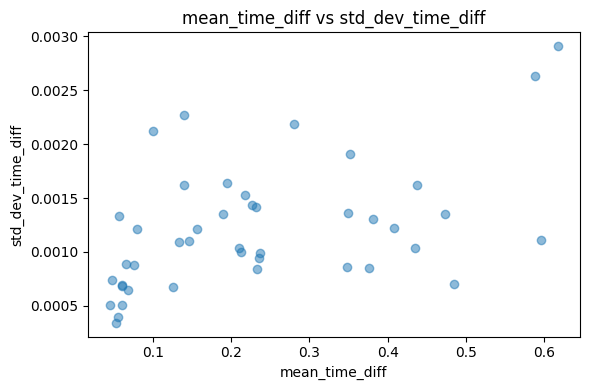

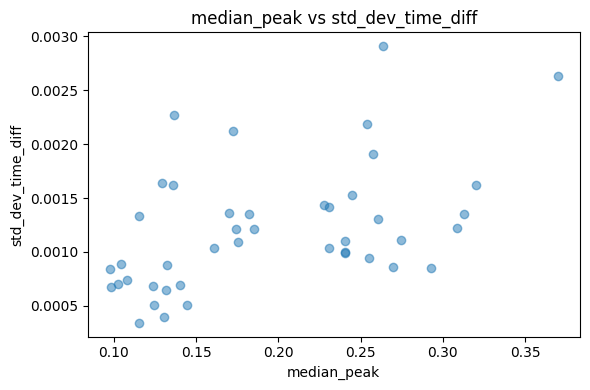

In [63]:
import matplotlib.pyplot as plt

target = 'std_dev_time_diff'

SigCols = [
  'mean_time_diff',
'median_peak'  
]

for col in df.columns:
    if col != target and col in SigCols:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[col], df[target], alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f'{col} vs {target}')
        plt.tight_layout()
        plt.show()


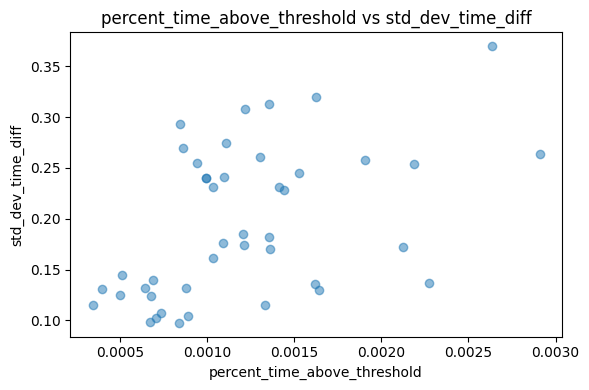

np.float64(0.47810496397148466)

In [67]:
plt.figure(figsize=(6, 4))
plt.scatter(df['std_dev_time_diff'], df['median_peak'], alpha=0.5)
plt.xlabel(col)
plt.ylabel(target)
plt.title(f'{col} vs {target}')
plt.tight_layout()
plt.show()

df['std_dev_time_diff'].corr(df['median_peak'])

In [65]:
target = 'std_dev_time_diff'
significant_predictors = []

for col in df.columns:
    if col != target:
        x = df[col]
        y = df[target]

        slope, intercept, r_value, p_value, std_err = linregress(x, y)

        if p_value < 0.05:
            significant_predictors.append((col, slope, p_value))

# Print results
print("Significant Predictors (p < 0.05):\n")
for var, beta, p in significant_predictors:
    print(f"{var}: β̂ = {beta:.4f}, p-value = {p:.4g}")

Significant Predictors (p < 0.05):

mean_time_diff: β̂ = 0.0017, p-value = 0.001008
median_time_diff: β̂ = 0.0017, p-value = 0.001
max_peak: β̂ = 0.0033, p-value = 0.002308
median_peak: β̂ = 0.0038, p-value = 0.001184


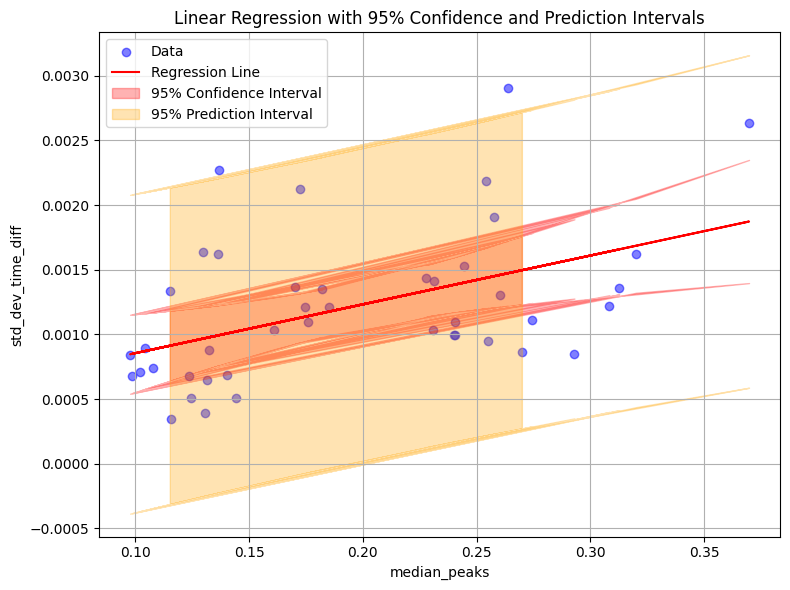

[0.00271885 0.00234989 0.00269293 0.00216534 0.0028827  0.00211217
 0.00213809 0.00229655 0.00237315 0.00219218 0.00273786 0.00232937
 0.0023377  0.00207893 0.00290147 0.00208179 0.00221055 0.00209391
 0.00259871 0.0023455  0.00223715 0.00219512 0.00281631 0.00261508
 0.00254879 0.00265369 0.00266828 0.00218993 0.00238432 0.00267906
 0.00216885 0.00220841 0.00210061 0.00293415 0.00315875 0.00259905
 0.00265824 0.00256106 0.00218567 0.00256057 0.00259765 0.00222218
 0.00213678]


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Prepare data
X = df[['median_peak']].values
y = df['std_dev_time_diff'].values

# Fit model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Compute standard error
n = len(X)
X_mean = np.mean(X)
se = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2))
t = 2.326  # for 95% CI and PI

# Confidence interval for the regression line
X_flat = X.flatten()
y_pred_flat = y_pred.flatten()
ci_term = np.sqrt(1/n + (X_flat - X_mean) ** 2 / np.sum((X_flat - X_mean) ** 2))
ci = t * se * ci_term
lower_ci = y_pred_flat - ci
upper_ci = y_pred_flat + ci

# Prediction interval (PI)
pi = t * se * np.sqrt(1 + ci_term**2)  # Note the +1 inside the sqrt for prediction
pi_lower = y_pred_flat - pi
pi_upper = y_pred_flat + pi

# Plot with CI and PI
plt.figure(figsize=(8, 6))
plt.scatter(X_flat, y, alpha=0.5, label='Data', color='blue')
plt.plot(X_flat, y_pred_flat, color='red', label='Regression Line')

# Plot Confidence Interval
plt.fill_between(X_flat, lower_ci, upper_ci, color='red', alpha=0.3, label='95% Confidence Interval')

# Plot Prediction Interval
plt.fill_between(X_flat, pi_lower, pi_upper, color='orange', alpha=0.3, label='95% Prediction Interval')

plt.xlabel('median_peaks')
plt.ylabel('std_dev_time_diff')
plt.title('Linear Regression with 95% Confidence and Prediction Intervals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(pi_upper)